# Insert/Delete D3PM Exploration (AA toy)

This notebook is a sandbox for `google_d3pm_ins_del` only (JAX side), with small amino-acid toy sequences.

It covers:
- build a `OneStepDistn`
- run `sample_noise_step` and `align_one_step`
- compute `multi_step_aligned_log_prob` and DP table sanity values
- define AA tokenization + sentinel conventions
- show JAX -> PyTorch handoff shape for future integration


In [8]:
import math
from dataclasses import dataclass

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from google_d3pm_ins_del import forward_process as fp
from google_d3pm_ins_del import transition_operator as to
from google_d3pm_ins_del import training_setup

try:
    import torch
except Exception:
    torch = None

print('jax', jax.__version__)
if torch is not None:
    print('torch', torch.__version__)


jax 0.5.2
torch 2.9.1


In [9]:
# ----- Tokenization and sentinels -----
# Keep sentinels from google code:
INS = fp.DynamicLengthSentinelSequence.INSERT_SENTINEL   # -1
DEL = fp.DynamicLengthSentinelSequence.DELETE_SENTINEL   # -2
ERR = fp.DynamicLengthSentinelSequence.ERROR             # -3

# Task-token vocab for diffusion: 20 amino acids only (no PAD/EOS).
AA_LIST = list('ACDEFGHIKLMNPQRSTVWY')
VOCAB = list(AA_LIST)
aa2id = {tok: i for i, tok in enumerate(VOCAB)}
id2aa = {i: tok for tok, i in aa2id.items()}

def encode_aa_string(seq):
    ids = [aa2id[ch] for ch in seq]
    return ids

def decode_token_ids(ids):
    out = []
    for t in ids:
        if t == INS:
            out.append('<INS>')
        elif t == DEL:
            out.append('<DEL>')
        elif t == ERR:
            out.append('<ERR>')
        else:
            out.append(id2aa.get(int(t), f'<UNK:{int(t)}>'))
    return out

def make_dyn_seq(token_ids, max_len):
    tok = np.full((max_len,), ERR, dtype=np.int32)
    n = min(len(token_ids), max_len)
    tok[:n] = np.array(token_ids[:n], dtype=np.int32)
    return fp.DynamicLengthSentinelSequence(tokens=jnp.array(tok), length=jnp.array(n, dtype=jnp.int32))

def dyn_seq_to_list(ds):
    n = int(ds.length)
    return [int(x) for x in np.array(ds.tokens[:n])]

print('vocab_size:', len(VOCAB))
print('sentinels:', {'INS': INS, 'DEL': DEL, 'ERR': ERR})


vocab_size: 20
sentinels: {'INS': -1, 'DEL': -2, 'ERR': -3}


In [10]:
def make_one_step_distn(vocab_size, p_delete=0.12, p_insert=0.18, stay_prob=0.90):
    """Construct a simple OneStepDistn for toy experiments."""
    assert 0.0 < p_delete < 1.0
    assert 0.0 < p_insert < 1.0
    assert 0.0 < stay_prob < 1.0

    # Row-stochastic A: mostly keep token, small chance to transition to others.
    off = (1.0 - stay_prob) / (vocab_size - 1)
    mat = np.full((vocab_size, vocab_size), off, dtype=np.float32)
    np.fill_diagonal(mat, stay_prob)

    # Insert distribution: uniform over amino acids.
    insert_logits = np.full((vocab_size,), -np.inf, dtype=np.float32)
    valid_insert_ids = [aa2id[a] for a in AA_LIST]
    insert_logits[valid_insert_ids] = 0.0
    insert_logits = jax.nn.log_softmax(jnp.array(insert_logits))

    return fp.OneStepDistn(
        lp_delete=jnp.log(jnp.array(p_delete, dtype=jnp.float32)),
        lp_insert=jnp.log(jnp.array(p_insert, dtype=jnp.float32)),
        A=to.MatrixOperator(jnp.array(mat)),
        D_insert_logits=insert_logits,
    )

one_step = make_one_step_distn(len(VOCAB), p_delete=0.15, p_insert=0.2, stay_prob=0.88)
print('one_step.lp_delete=', float(one_step.lp_delete), 'one_step.lp_insert=', float(one_step.lp_insert))


one_step.lp_delete= -1.8971199989318848 one_step.lp_insert= -1.6094379425048828


In [11]:
toy_aa = [
    'ACDEG',
    'MNPQRST',
    'ACDEFGHIKLMNPQ',
    'GGGGGTTTTTAAAAA',
    'ACDEFGHIKLMNPQRSTVWY',
]
max_len = 64

x0_list = [make_dyn_seq(encode_aa_string(s), max_len=max_len) for s in toy_aa]

for i, x0 in enumerate(x0_list):
    toks = dyn_seq_to_list(x0)
    print(i, toy_aa[i], '->', toks)


0 ACDEG -> [0, 1, 2, 3, 5]
1 MNPQRST -> [10, 11, 12, 13, 14, 15, 16]
2 ACDEFGHIKLMNPQ -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
3 GGGGGTTTTTAAAAA -> [5, 5, 5, 5, 5, 16, 16, 16, 16, 16, 0, 0, 0, 0, 0]
4 ACDEFGHIKLMNPQRSTVWY -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [12]:
import jax
# Sample one noising step and infer one-step alignment
rng = jax.random.PRNGKey(0)
samples = []
for i, x0 in enumerate(x0_list):
    rng, k = jax.random.split(rng)
    xt1, align_sampled = fp.sample_noise_step(x0, one_step, k)
    align_inferred = fp.align_one_step(x0, xt1)

    samples.append((x0, xt1, align_sampled, align_inferred))

    print(f'Example {i}')
    print('  x0 :', decode_token_ids(dyn_seq_to_list(x0)))
    print('  xt1:', decode_token_ids(dyn_seq_to_list(xt1)))
    print('  lengths:', int(x0.length), '->', int(xt1.length))
    print('  inferred alignment is_single_step:', bool(align_inferred.is_single_step))
    print()


Example 0
  x0 : ['A', 'C', 'D', 'E', 'G']
  xt1: ['<INS>', 'Q', 'C', 'D', 'E', 'G']
  lengths: 5 -> 6
  inferred alignment is_single_step: True

Example 1
  x0 : ['M', 'N', 'P', 'Q', 'R', 'S', 'T']
  xt1: ['M', '<INS>', 'H', '<INS>', 'P', '<DEL>', '<INS>', 'D', 'S', '<DEL>']
  lengths: 7 -> 10
  inferred alignment is_single_step: True

Example 2
  x0 : ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q']
  xt1: ['A', 'H', '<INS>', '<INS>', 'I', 'E', '<DEL>', 'G', '<DEL>', 'I', 'K', 'L', 'M', '<DEL>', 'P', 'Q']
  lengths: 14 -> 16
  inferred alignment is_single_step: True

Example 3
  x0 : ['G', 'G', 'G', 'G', 'G', 'T', 'T', 'T', 'T', 'T', 'A', 'A', 'A', 'A', 'A']
  xt1: ['G', 'G', 'G', 'G', 'G', 'T', '<INS>', '<DEL>', '<DEL>', 'E', 'T', '<INS>', '<INS>', 'A', 'A', 'A', 'A', 'A']
  lengths: 15 -> 18
  inferred alignment is_single_step: True

Example 4
  x0 : ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
  xt1: ['A

source: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q']
target: ['A', 'H', '<INS>', '<INS>', 'I', 'E', '<DEL>', 'G', '<DEL>', 'I', 'K', 'L', 'M', '<DEL>', 'P', 'Q']
backpointers: [0, 1, -1, -1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


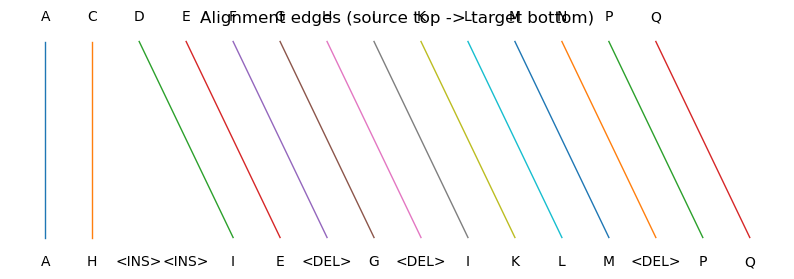

In [13]:
# Optional quick alignment visualization for one example
ex = 2
x0, xt1, align_sampled, align_inferred = samples[ex]

src = decode_token_ids(dyn_seq_to_list(x0))
tgt = decode_token_ids(dyn_seq_to_list(xt1))
bp = np.array(align_inferred.backpointers[:int(align_inferred.after_length)])

print('source:', src)
print('target:', tgt)
print('backpointers:', bp.tolist())

fig, ax = plt.subplots(1, 1, figsize=(10, 2.8))
ax.axis('off')
for i, tok in enumerate(src):
    ax.text(i, 1.0, tok, ha='center', va='center')
for j, tok in enumerate(tgt):
    ax.text(j, 0.0, tok, ha='center', va='center')
for j, i in enumerate(bp):
    if i >= 0 and i < len(src):
        ax.plot([i, j], [0.9, 0.1], linewidth=1.0)
ax.set_title('Alignment edges (source top -> target bottom)')
plt.show()


In [ ]:
# multi_step_aligned_log_prob sanity on same sampled pair
import torch


x0, xt1, _, align = samples[0]
many = fp.ManyStepDistn.from_single_step(one_step)

lp = fp.multi_step_aligned_log_prob(x0, xt1, align, many)
print('multi_step_aligned_log_prob (single-step distn via ManyStepDistn):', float(lp))

# DP table over all alignments for same (source, target)
log_gen, log_take = fp.compute_multi_step_alignment_table(x0, xt1, many, pack_block_size=16)
i = int(x0.length)
j = int(xt1.length)
print('table terminal log_take[length_x0, length_xt1]=', float(log_take[i, j]))

multi_step_aligned_log_prob (single-step distn via ManyStepDistn): -9.336930274963379
table terminal log_take[length_x0, length_xt1]= -9.336929321289062
<class 'jaxlib.xla_extension.ArrayImpl'> <class 'jaxlib.xla_extension.ArrayImpl'>


In [ ]:
# Build a small multi-step schedule using training_setup helper
@dataclass
class DummyDatasetInfo:
    vocab: list

dataset_info = DummyDatasetInfo(vocab=VOCAB)
state = training_setup.state_init_fn(
    dataset_info,
    transition_type='uniform',
    insert_type='uniform',
    num_steps=8,
    final_relative_size=0.7,
    final_refresh_prob=0.05,
    initial_slope=1.0,
    acceleration=4,
)
schedule = state.model_state['schedule']
print('schedule.num_steps:', schedule.num_steps)

# Example: sample x_t from x_0 using cumulative[t]
x0 = x0_list[1]
t = 3
d_0_to_t = jax.tree.map(lambda x: x[t], schedule.cumulative)
rng, k = jax.random.split(rng)
xt, a_0_t = fp.sample_noise_step(x0, d_0_to_t, k)

print('x0 length:', int(x0.length), 'xt length:', int(xt.length), 't=', t)
print('x0:', decode_token_ids(dyn_seq_to_list(x0)))
print('xt:', decode_token_ids(dyn_seq_to_list(xt)))


In [ ]:
# JAX -> PyTorch handoff prototype for future integration
# target tuple style: (x_t, t, targets)
if torch is None:
    print('torch not installed in this kernel')
else:
    x_t_np = np.array(xt.tokens, dtype=np.int64)
    t_np = np.int64(t)

    # Minimal target for Phase A: reconstruct x0 token ids.
    target_x0_np = np.array(x0.tokens, dtype=np.int64)

    batch = {
        'x_t': torch.from_numpy(x_t_np)[None, :],
        't': torch.tensor([t_np], dtype=torch.long),
        'target_x0': torch.from_numpy(target_x0_np)[None, :],
        'len_t': torch.tensor([int(xt.length)], dtype=torch.long),
        'len_x0': torch.tensor([int(x0.length)], dtype=torch.long),
    }

    for k, v in batch.items():
        print(k, tuple(v.shape), v.dtype)


## Notes for integration

- Sentinel values stay in the dynamic sequence wrapper (`INS=-1`, `DEL=-2`, `ERR=-3`) and are not part of AA vocab indices.
- Suggested dataset fields for Phase A handoff: `x_t_tokens`, `x_t_len`, `t`, `x0_tokens`, `x0_len`, and optional alignment stats.
- Phase B can replace `target_x0` with edit-marginal targets from `intermediate_marginals(...)`.
